In [ ]:
#import libraries
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [ ]:
#load dataset into dataframes
salary_df = pd.read_csv('/content/clean_salary_dataset.csv')

In [ ]:
#display first five rows
salary_df.head()

,EmployeeID,Age,YearsExperience,YearsAtCompany,Department,EducationLevel,PerformanceRating,MonthlyHoursWorked,MonthlySalary,PerformanceRating_missing
0,1,44,26,13.0,Sales,Bachelor,4.0,160.0,167000.0,0
1,2,38,18,0.0,Engineering,Bachelor,4.0,163.0,174000.0,0
2,3,46,24,3.0,Sales,Master,5.0,159.0,223000.0,0
3,4,55,31,12.0,Engineering,High School,1.0,148.0,125000.0,0
4,5,37,17,11.0,HR,Bachelor,2.0,172.0,115000.0,0


In [ ]:
#one hot encode department and educationlevel
salary_df = pd.get_dummies(salary_df, columns=['Department', 'EducationLevel'], drop_first=True)

In [ ]:
#check for multicolinearity
salary_df[['Age','YearsExperience']].corr()

,Age,YearsExperience
Age,1.000000,0.958653
YearsExperience,0.958653,1.000000


In [ ]:
#drop employeeid and age
salary_df.drop(columns=['EmployeeID', 'Age'], inplace=True)

In [ ]:
salary_df.head()

,YearsExperience,YearsAtCompany,PerformanceRating,MonthlyHoursWorked,MonthlySalary,PerformanceRating_missing,Department_Finance,Department_HR,Department_Marketing,Department_Operations,Department_Sales,EducationLevel_High School,EducationLevel_Master,EducationLevel_PhD
0,26,13.0,4.0,160.0,167000.0,0,False,False,False,False,True,False,False,False
1,18,0.0,4.0,163.0,174000.0,0,False,False,False,False,False,False,False,False
2,24,3.0,5.0,159.0,223000.0,0,False,False,False,False,True,False,True,False
3,31,12.0,1.0,148.0,125000.0,0,False,False,False,False,False,True,False,False
4,17,11.0,2.0,172.0,115000.0,0,False,True,False,False,False,False,False,False


In [ ]:
#define features(X) and target variable(y)
X = salary_df.drop(columns=['MonthlySalary'])
y = salary_df['MonthlySalary']

In [ ]:
#display first five rows of features(X)
X.head()

,YearsExperience,YearsAtCompany,PerformanceRating,MonthlyHoursWorked,PerformanceRating_missing,Department_Finance,Department_HR,Department_Marketing,Department_Operations,Department_Sales,EducationLevel_High School,EducationLevel_Master,EducationLevel_PhD
0,26,13.0,4.0,160.0,0,False,False,False,False,True,False,False,False
1,18,0.0,4.0,163.0,0,False,False,False,False,False,False,False,False
2,24,3.0,5.0,159.0,0,False,False,False,False,True,False,True,False
3,31,12.0,1.0,148.0,0,False,False,False,False,False,True,False,False
4,17,11.0,2.0,172.0,0,False,True,False,False,False,False,False,False


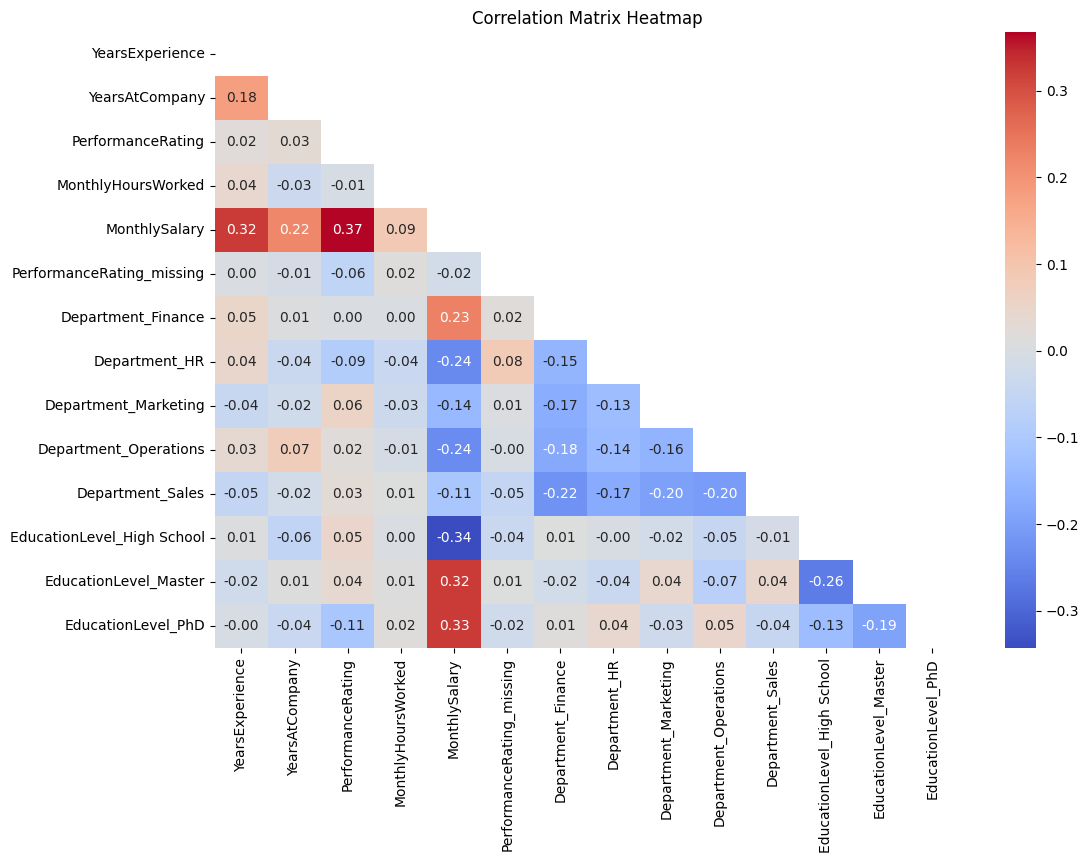

In [ ]:
#visualize with a heatmap
corr_matrix = salary_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:
#display first 5 rows of target(y)
y.head()

,MonthlySalary
0,167000.0
1,174000.0
2,223000.0
3,125000.0
4,115000.0


In [ ]:
# split dataset into test and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=234)

In [ ]:
#display shape
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 13), (200, 13), (800,), (200,))

In [ ]:
y.mean()

np.float64(152093.0)

In [ ]:
#train the data using linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
#predict the test data
y_pred_lr = lr.predict(X_test)

In [ ]:
#display key metrics
print("Linear Regression R2:", round(r2_score(y_test, y_pred_lr),3))
print("Linear Regression MAE:", round(mean_absolute_error(y_test, y_pred_lr),3))
print("Linear Regression RMSE:", round(root_mean_squared_error(y_test, y_pred_lr),3))

Linear Regression R2: 0.899
Linear Regression MAE: 9869.844
Linear Regression RMSE: 12940.365


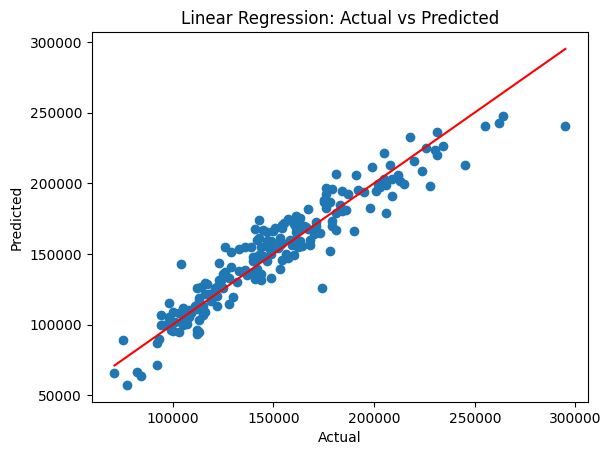

In [ ]:
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


In [ ]:
#display actual ,predicted and residual values for ensemble model
lr_result = pd.DataFrame({"Actual(y)": y_test, "Predicted(y)": y_pred_lr})
lr_diff = pd.DataFrame({"Difference": abs(y_test - y_pred_lr)})
lr_result["Difference(residual)"] = lr_diff["Difference"]
lr_result.head()

,Actual(y),Predicted(y),Difference(residual)
809,198000.0,182260.130232,15739.869768
891,152000.0,153790.120684,1790.120684
328,153000.0,139571.285118,13428.714882
297,154000.0,157411.552436,3411.552436
319,122000.0,120496.842366,1503.157634


In [ ]:
#train using random forest
rf = RandomForestRegressor(n_estimators=100, random_state=234)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=234)

In [ ]:
#predict the test data
y_pred_rf = rf.predict(X_test)

In [ ]:
#display key metrics
print("Random Forest R2:", round(r2_score(y_test, y_pred_rf),3))
print("Random Forest MAE:", round(mean_absolute_error(y_test, y_pred_rf),3))
print("Random Forest MSE:", round(root_mean_squared_error(y_test, y_pred_rf),3))

Random Forest R2: 0.81
Random Forest MAE: 13218.75
Random Forest MSE: 17770.998


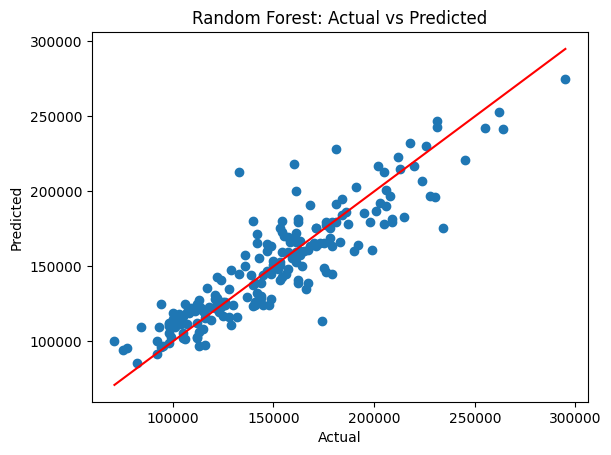

In [ ]:
#display actual vs predicted
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


In [ ]:
#display actual ,predicted and residual values for random forest model
rf_result = pd.DataFrame({"Actual(y)": y_test, "Predicted(y)": y_pred_rf})
rf_diff = pd.DataFrame({"Difference": abs(y_test - y_pred_rf)})
rf_result["Difference(residual)"] = rf_diff["Difference"]
rf_result.head()

,Actual(y),Predicted(y),Difference(residual)
809,198000.0,179840.0,18160.0
891,152000.0,148500.0,3500.0
328,153000.0,140750.0,12250.0
297,154000.0,172890.0,18890.0
319,122000.0,142990.0,20990.0


In [ ]:
#train using an ensemble model
ensemble = VotingRegressor(estimators=[('lr', lr), ('rf', rf)])
ensemble.fit(X_train, y_train)

VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('rf', RandomForestRegressor(random_state=234))])

In [ ]:
#predict using the test data
y_pred_ensemble = ensemble.predict(X_test)

In [ ]:
#key metrics
print("Ensemble R2:", round(r2_score(y_test, y_pred_ensemble),3))
print("Ensemble MAE:", round(mean_absolute_error(y_test, y_pred_ensemble),3))
print("Ensemble RMSE:", round(root_mean_squared_error(y_test, y_pred_ensemble),3))

Ensemble R2: 0.907
Ensemble MAE: 9198.097
Ensemble RMSE: 12451.202


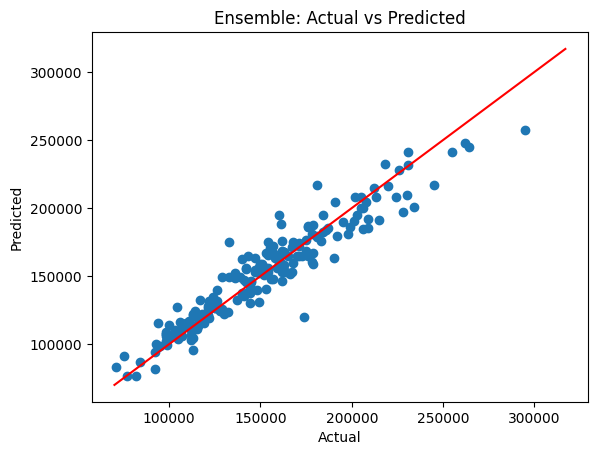

In [ ]:
#display using scatter plots
plt.scatter(y_test, y_pred_ensemble)
plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red')
plt.title("Ensemble: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [ ]:
#display actual ,predicted and residual values for ensemble model
ensemble_result = pd.DataFrame({"Actual(y)": y_test, "Predicted(y)": y_pred_ensemble})
ensemble_diff = pd.DataFrame({"Difference": abs(y_test - y_pred_ensemble)})
ensemble_result["Difference(residual)"] = ensemble_diff["Difference"]
ensemble_result.head()

,Actual(y),Predicted(y),Difference(residual)
809,198000.0,181050.065116,16949.934884
891,152000.0,151145.060342,854.939658
328,153000.0,140160.642559,12839.357441
297,154000.0,165150.776218,11150.776218
319,122000.0,131743.421183,9743.421183


:Since the ensemble model of the linear regression and random forest performed better then this would be used.

In [ ]:
#retrain on the whole dataset
ensemble.fit(X, y)

VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('rf', RandomForestRegressor(random_state=234))])

In [ ]:
#save column order
feature_order = X.columns

In [ ]:
#test prediction
#create a function
def predict_salary(input_dict):

  #convert the input values into a dataframe
  input_df = pd.DataFrame([input_dict])

  #one hot encode
  input_encode = pd.get_dummies(input_df)

  #align columns with training data
  input_encode = input_encode.reindex(columns=feature_order, fill_value=0)

  #predict
  prediction = ensemble.predict(input_encode)
  rounded_salary = np.round(prediction[0])

  #return the prediction
  return rounded_salary




In [ ]:
#input values
input_dict = {
    'Age':35,
    'YearsExperience':16,
    'YearsAtCompany':0,
    'Department': 'Marketing',
    'EducationLevel': 'Bachelor',
    'PerformanceRating':4,
    'MonthlyHoursWorked':174,
    'PerformanceRating_missing':0
}

predict_salary(input_dict)

np.float64(136228.0)